In [1]:
import pandas as pd
from datetime import datetime

import matplotlib.pyplot as plt

In [2]:
path = r'../11_how to check nft wallet transactions/doodles_transfers_last_6_months.csv'

# read csv from path
doodles_transfers_last_6_months = pd.read_csv(path)

# Convert 'timeStamp' to datetime
doodles_transfers_last_6_months['timeStamp'] = pd.to_datetime(doodles_transfers_last_6_months['timeStamp'], unit='s')

# doodles_transfers_last_6_months.head(5)

In [3]:
doodles_transfers_last_6_months.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7072 entries, 0 to 7071
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   blockNumber        7072 non-null   int64         
 1   timeStamp          7072 non-null   datetime64[ns]
 2   hash               7072 non-null   object        
 3   nonce              7072 non-null   int64         
 4   blockHash          7072 non-null   object        
 5   from               7072 non-null   object        
 6   contractAddress    7072 non-null   object        
 7   to                 7072 non-null   object        
 8   tokenID            7072 non-null   int64         
 9   tokenName          7072 non-null   object        
 10  tokenSymbol        7072 non-null   object        
 11  tokenDecimal       7072 non-null   int64         
 12  transactionIndex   7072 non-null   int64         
 13  gas                7072 non-null   int64         
 14  gasPrice

In [4]:
# doodles_transfers_last_6_months.head()
doodles_transfers_last_6_months.tail()

,blockNumber,timeStamp,hash,nonce,blockHash,from,contractAddress,to,tokenID,tokenName,...,tokenDecimal,transactionIndex,gas,gasPrice,gasUsed,cumulativeGasUsed,input,methodId,functionName,confirmations
7067,23678092,2025-10-28 19:47:59,0x0c03d66b5b0eea81e862b608c37df83f108f5d896c2f...,1824,0x92e29f03618b27b054a7225ced1d624cd8b27c0791bc...,0x4a6cb72561623271a84490191f2429ebb611dd51,0x8a90cab2b38dba80c64b7734e58ee1db38b8992e,0x2a9a6bf65ab612e4bb3c5dc7478d45dc17ffd5de,5602,Doodles,...,0,130,295403,320694965,226522,23757539,deprecated,0xe7acab24,JunionWasHereXD_ufpfzhujazyn(),1287676
7068,23678040,2025-10-28 19:37:35,0x282fe0a2b6b99085a3274a5a5e518773f5c0b83dcd5b...,4823,0xc0377c3d16f07b14da9f3865306e80529bf7c070357d...,0x96e4a596087b811d61216684a4d87c688c6cbffa,0x8a90cab2b38dba80c64b7734e58ee1db38b8992e,0x3d16a61098be6d642c6125ba0ba854821ced60b4,3066,Doodles,...,0,135,133125,1317399763,88750,20806906,deprecated,0xb88d4fde,"safeTransferFrom(address from, address to, uin...",1287728
7069,23677945,2025-10-28 19:17:59,0x8c714e4507a060dff6f33f66906d858c09df9bbf5b33...,2591,0xf0b2bb472d8e98f8f337c373de8301778a95afb38a7e...,0xfee2c0c52eb0f05f3dccccd0d857bc0f3f9f6c94,0x8a90cab2b38dba80c64b7734e58ee1db38b8992e,0x29469395eaf6f95920e59f858042f0e28d98a20b,1666,Doodles,...,0,41,215958,2140783146,202568,4338380,deprecated,0xe263967e,"borrow(tuple offer,bytes signature,uint256 loa...",1287823
7070,23677827,2025-10-28 18:53:59,0x5ba6b16bdc8f0e275a139c43e21fac0a10d86c6761ca...,508,0x80c826e3123c6a666dd2b3cf5d65bdd0f3c26c022622...,0x4677de80b1c6156c855db804dc20bf02337f000e,0x8a90cab2b38dba80c64b7734e58ee1db38b8992e,0x29469395eaf6f95920e59f858042f0e28d98a20b,8717,Doodles,...,0,23,215978,2142083899,202588,1964961,deprecated,0xe263967e,"borrow(tuple offer,bytes signature,uint256 loa...",1287941
7071,23677647,2025-10-28 18:17:35,0x355c41d3cac39d3843db9e511e90e7e711d4bc48b511...,578,0xd3f79e5c679e761a9ab8ba8123b3cfdf2492a0f4c8a5...,0x29469395eaf6f95920e59f858042f0e28d98a20b,0x8a90cab2b38dba80c64b7734e58ee1db38b8992e,0x72d3197aefd502334c0eadde782ccb42cadfb784,5743,Doodles,...,0,4,359769,2174530233,201984,867227,deprecated,0x8553b234,"buyLockedETH(tuple lien,tuple offer,bytes sign...",1288121


In [5]:
# tokenName unique values
unique_token_names = doodles_transfers_last_6_months['tokenName'].unique()
print(unique_token_names)         

['Doodles']


In [6]:
# timeStamp min and max values
min_timestamp = doodles_transfers_last_6_months['timeStamp'].min()
max_timestamp = doodles_transfers_last_6_months['timeStamp'].max()
print(f"Min timestamp: {min_timestamp}")
print(f"Max timestamp: {max_timestamp}")

Min timestamp: 2025-10-28 18:17:35
Max timestamp: 2026-04-26 11:37:59


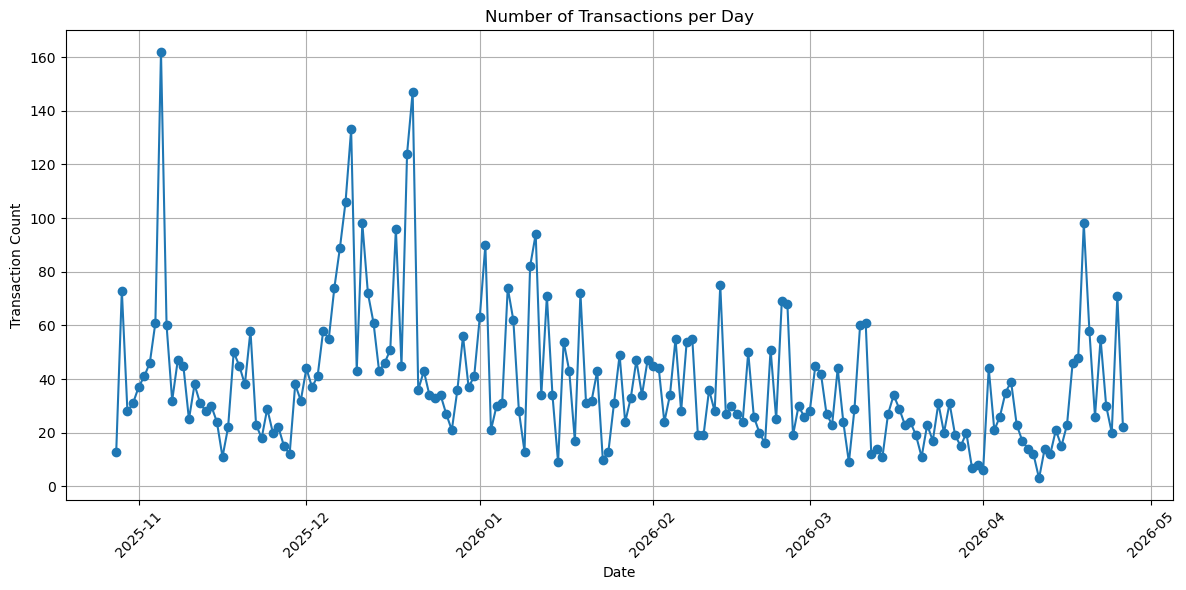

In [7]:
# divide timestamp into date and time
# group by date and count the number of transactions per day
grouped_by_date = doodles_transfers_last_6_months.groupby(doodles_transfers_last_6_months['timeStamp'].dt.date).size().reset_index(name='transaction_count')

# plot the number of transactions per day
plt.figure(figsize=(12, 6))
plt.plot(grouped_by_date['timeStamp'], grouped_by_date['transaction_count'], marker='o')
plt.title('Number of Transactions per Day')
plt.xlabel('Date')  
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [8]:
# group by timeStamp and count tokenID
grouped_data = doodles_transfers_last_6_months.groupby('timeStamp')['tokenID'].count().reset_index()
grouped_data.columns = ['timeStamp', 'tokenID_count']

grouped_data.head()

,timeStamp,tokenID_count
0,2025-10-28 18:17:35,1
1,2025-10-28 18:53:59,1
2,2025-10-28 19:17:59,1
3,2025-10-28 19:37:35,1
4,2025-10-28 19:47:59,1


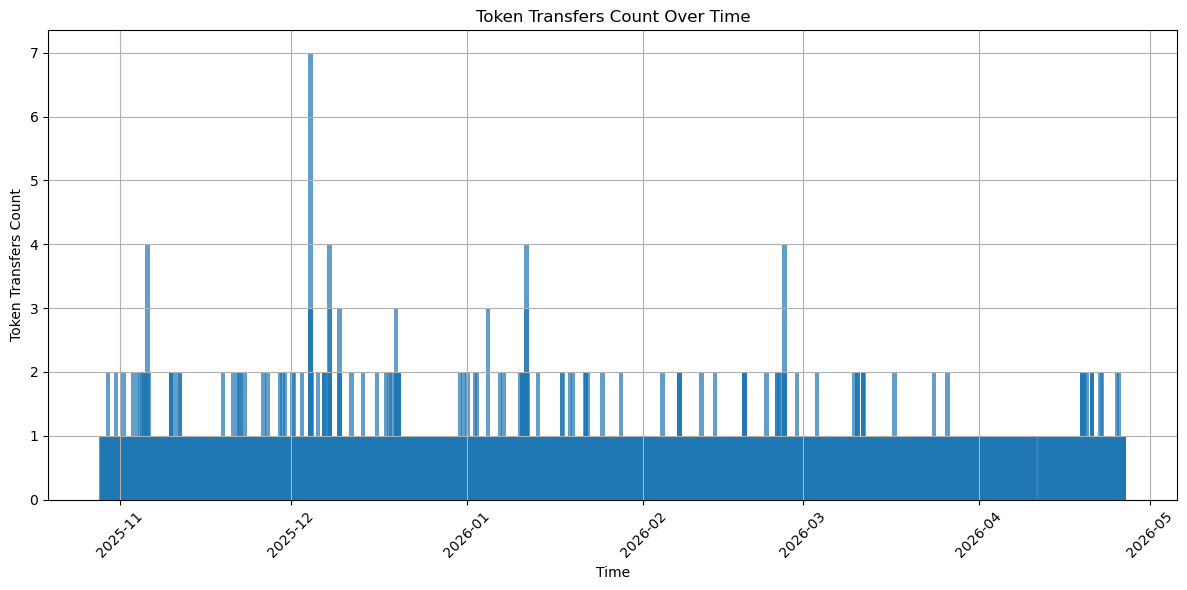

In [9]:
# plot the data
plt.figure(figsize=(12, 6))
plt.bar(grouped_data['timeStamp'], grouped_data['tokenID_count'], alpha=0.7)
plt.title('Token Transfers Count Over Time')
plt.xlabel('Time')
plt.ylabel('Token Transfers Count')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [10]:
# transactions to whale wallets to identify potential whale activity

whales_path = r'../11_how to check nft wallet transactions/Doodles.xlsx'
whales_df = pd.read_excel(whales_path)

# Display the first few rows of the whales DataFrame
whales_df.head()

,wallet
0,0xAd71Ad65d9a7E238F5d6145c92E2eEB00b6C3b1b
1,0x958ab8695f33Cc5BeccBCb90B5A6c11B5f705e39
2,0xA71365a3A7f4f6a9F4AC18d65Ab338E0C9708830
3,0x0C37f1FC90BF56387B59615508bbd975D448856F
4,0x9b37BC499De5e675063695211618F3Cd64A1B9Fc


In [11]:
# Creare una colonna whales_count per identificare transazioni verso whale wallets
# Se doodles_transfers_last_6_months.to è uguale a un wallet in whales_df.wallet, 
# allora whales_count = 1, altrimenti 0

# Convertire i wallet addresses a lowercase per un confronto case-insensitive
whales_wallets = whales_df['wallet'].str.lower().tolist()
doodles_transfers_last_6_months['to_lower'] = doodles_transfers_last_6_months['to'].str.lower()

# Creare la colonna whales_count: 1 se il wallet di destinazione è un whale, 0 altrimenti
doodles_transfers_last_6_months['whales_count'] = doodles_transfers_last_6_months['to_lower'].isin(whales_wallets).astype(int)

# Rimuovere la colonna temporanea to_lower
doodles_transfers_last_6_months.drop(columns=['to_lower'], inplace=True)

# Mostrare le statistiche dei whale transfers
whale_transfers_count = doodles_transfers_last_6_months['whales_count'].sum()
total_transfers = len(doodles_transfers_last_6_months)

print(f"Total transfers: {total_transfers}")
print(f"Transfers to whale wallets: {whale_transfers_count}")
print(f"Percentage of transfers to whales: {whale_transfers_count/total_transfers*100:.2f}%")

# Mostrare le prime righe con la nuova colonna
doodles_transfers_last_6_months[['from', 'to', 'tokenID', 'whales_count']].head(10)

Total transfers: 7072
Transfers to whale wallets: 573
Percentage of transfers to whales: 8.10%


,from,to,tokenID,whales_count
0,0xd711e8975f248216dba4730c06fc86b9aa765f92,0x29469395eaf6f95920e59f858042f0e28d98a20b,944,0
1,0x65ba4f92d7dfa813ddbd849d9faf38a723dd9b12,0x2dfcec0f3dd9ee32eff4f1ddfba94ef578e051b8,1806,0
2,0x88b835e481cabef3c7c35e4007b2f413aab7755f,0xd711e8975f248216dba4730c06fc86b9aa765f92,944,0
3,0xd711e8975f248216dba4730c06fc86b9aa765f92,0x29469395eaf6f95920e59f858042f0e28d98a20b,8565,0
4,0x2dfcec0f3dd9ee32eff4f1ddfba94ef578e051b8,0x88b835e481cabef3c7c35e4007b2f413aab7755f,944,0
5,0x1daf53e752ad80c38a5653c9c5e2ab8c16cdcbd0,0xd711e8975f248216dba4730c06fc86b9aa765f92,8565,0
6,0x29469395eaf6f95920e59f858042f0e28d98a20b,0xaee434ee25dd70a2ac746c2ff78cff2b66ffbf41,1402,0
7,0xe02d85e80c1ebda5aa43b8a1996332a83f855a59,0xc19dc40f81aa9bfeda63f26ccd33aa465e7aa61a,3881,0
8,0x7f4d6c4ba570a6033907b9c0a653032f6c2fdd31,0x29469395eaf6f95920e59f858042f0e28d98a20b,9849,0
9,0x29469395eaf6f95920e59f858042f0e28d98a20b,0x7f4d6c4ba570a6033907b9c0a653032f6c2fdd31,9849,0


In [12]:
doodles_transfers_last_6_months.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7072 entries, 0 to 7071
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   blockNumber        7072 non-null   int64         
 1   timeStamp          7072 non-null   datetime64[ns]
 2   hash               7072 non-null   object        
 3   nonce              7072 non-null   int64         
 4   blockHash          7072 non-null   object        
 5   from               7072 non-null   object        
 6   contractAddress    7072 non-null   object        
 7   to                 7072 non-null   object        
 8   tokenID            7072 non-null   int64         
 9   tokenName          7072 non-null   object        
 10  tokenSymbol        7072 non-null   object        
 11  tokenDecimal       7072 non-null   int64         
 12  transactionIndex   7072 non-null   int64         
 13  gas                7072 non-null   int64         
 14  gasPrice

In [13]:
# group by date of timeStamp and sum() whales_count
grouped_whales_buys = doodles_transfers_last_6_months.groupby(doodles_transfers_last_6_months['timeStamp'].dt.date)['whales_count'].sum().reset_index()
grouped_whales_buys.columns = ['date', 'whales_count']

grouped_whales_buys.head()

,date,whales_count
0,2025-10-28,0
1,2025-10-29,12
2,2025-10-30,1
3,2025-10-31,0
4,2025-11-01,1


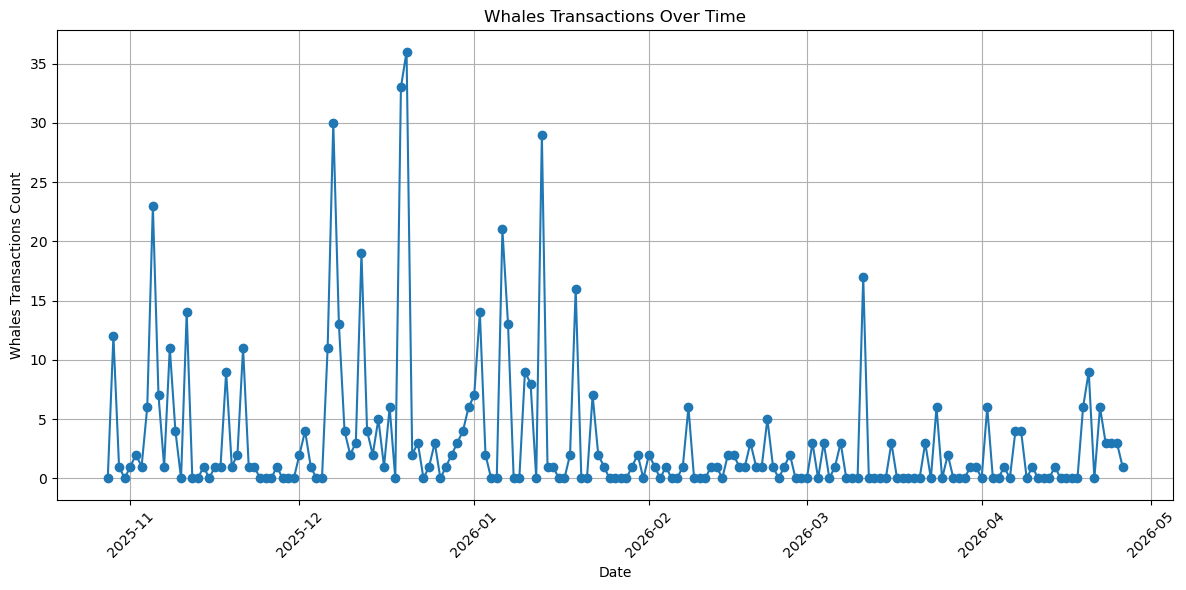

In [14]:
# plot the whales_count over time
plt.figure(figsize=(12, 6))
plt.plot(grouped_whales_buys['date'], grouped_whales_buys['whales_count'], marker='o')
plt.title('Whales Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Whales Transactions Count')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [15]:
# merge grouped_by_date with grouped_whales_buys on date
merged_data = pd.merge(grouped_by_date, grouped_whales_buys, left_on='timeStamp', right_on='date', how='left')
merged_data.rename(columns={'transaction_count': 'total_transactions', 'whales_count': 'whales_transactions'}, inplace=True)

# drop date
merged_data.drop(columns=['date'], inplace=True)

# set timeStamp as index
merged_data.set_index('timeStamp', inplace=True)

merged_data.head()

,total_transactions,whales_transactions
timeStamp,,
2025-10-28,13,0
2025-10-29,73,12
2025-10-30,28,1
2025-10-31,31,0
2025-11-01,37,1


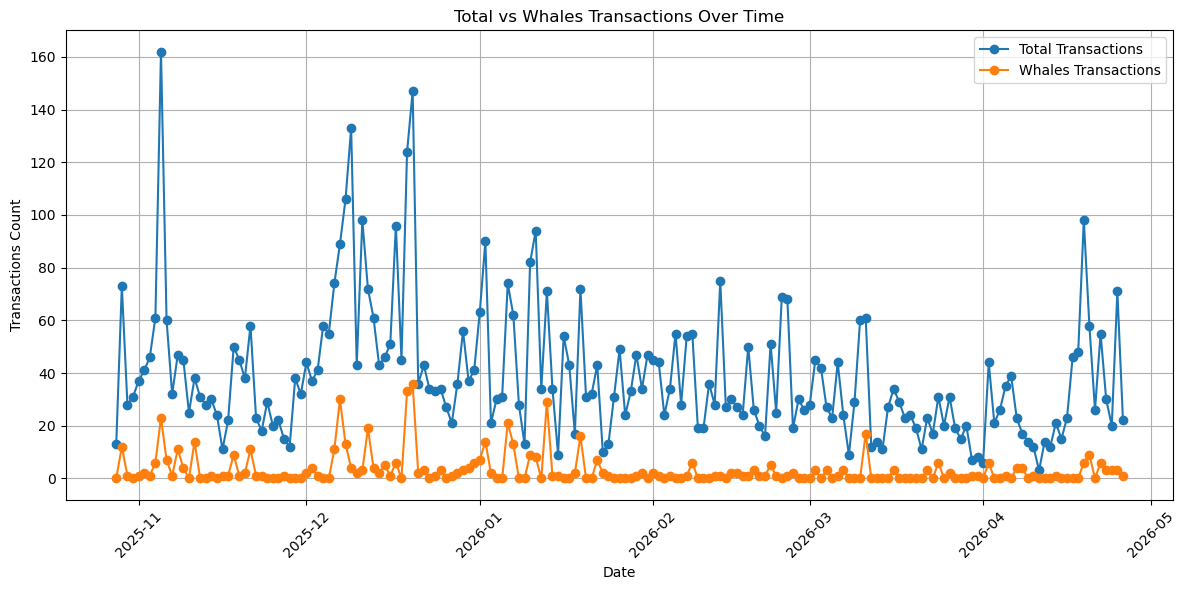

In [16]:
# plot total_transactions and whales_transactions
plt.figure(figsize=(12, 6))
plt.plot(merged_data.index, merged_data['total_transactions'], label='Total Transactions', marker='o')
plt.plot(merged_data.index, merged_data['whales_transactions'], label='Whales Transactions', marker='o')
plt.title('Total vs Whales Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Transactions Count')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()